In [11]:
# pip install scikit-learn pandas seaborn matplotlib
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, roc_auc_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier
sns.set_theme(style='whitegrid', context='notebook')
np.random.seed(0)

1) Data: Titanic (Seaborn)

In [12]:
df = sns.load_dataset('titanic').drop(columns=['alive'])
features = ['pclass','sex','age','sibsp','parch','fare','embarked']
target   = 'survived'
dfm = df[features + [target]].copy()

# quick fill for fare (others via pipeline)
dfm['fare'] = dfm['fare'].fillna(dfm['fare'].median())

X = dfm[features]
y = dfm[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

num = X.select_dtypes(include='number').columns.tolist()
cat = X.select_dtypes(exclude='number').columns.tolist()

pre = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num),
    ('cat', Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('oh',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), cat)
])

2) Models
Bagging: many trees trained on bootstrapped samples; reduces variance (unstable base learners benefit).

AdaBoost: sequentially focuses on errors; reduces bias (weak learners combined).

In [13]:
# Base learners
stump   = DecisionTreeClassifier(max_depth=1, random_state=0)   # weak learner (AdaBoost default)
dt_base = DecisionTreeClassifier(max_depth=None, random_state=0)

bag = Pipeline([
    ('prep', pre),
    ('clf',  BaggingClassifier(
        estimator=dt_base, n_estimators=200, max_samples=1.0,
        bootstrap=True, n_jobs=-1, random_state=0, oob_score=True
    ))
])

ada = Pipeline([
    ('prep', pre),
    ('clf',  AdaBoostClassifier(
        estimator=stump, n_estimators=200, learning_rate=0.5, random_state=0
    ))
])

3) Fit & evaluate

Bagging    | Acc=0.753  ROC-AUC=0.815


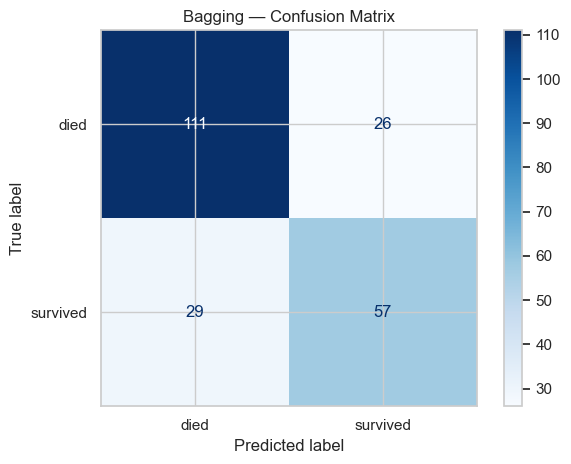

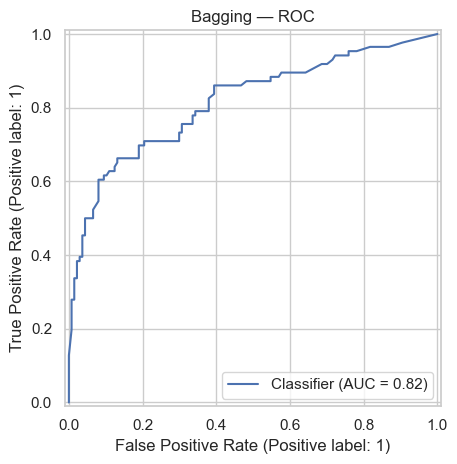

AdaBoost   | Acc=0.785  ROC-AUC=0.832


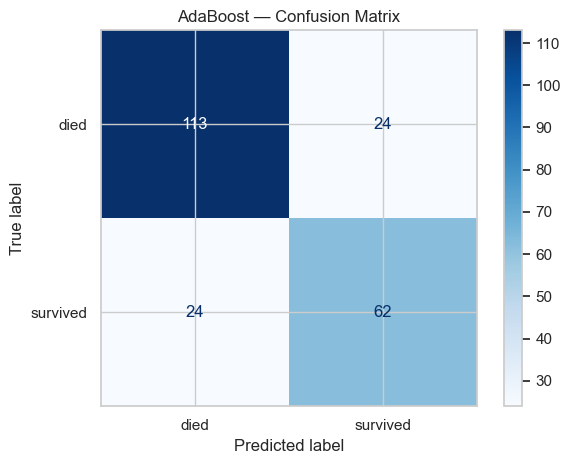

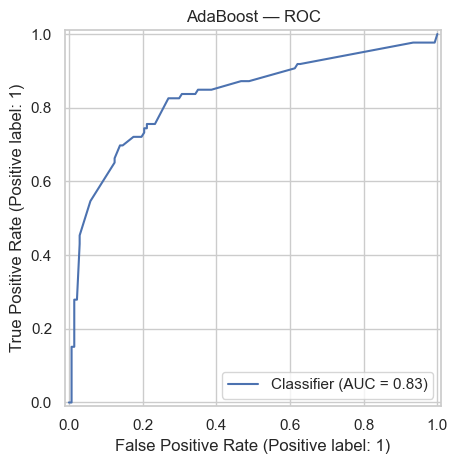

CV ROC‑AUC  Bagging: 0.859 ± 0.038
CV ROC‑AUC AdaBoost: 0.857 ± 0.019


In [14]:
bag.fit(X_train, y_train)
ada.fit(X_train, y_train)

def evaluate(model, name):
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    print(f"{name:10s} | Acc={acc:.3f}  ROC-AUC={auc:.3f}")
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                           display_labels=['died','survived']).plot(cmap='Blues')
    plt.title(name + " — Confusion Matrix"); plt.tight_layout(); plt.show()
    RocCurveDisplay.from_predictions(y_test, y_proba)
    plt.title(name + " — ROC"); plt.tight_layout(); plt.show()
    return acc, auc

acc_bag, auc_bag = evaluate(bag, "Bagging")
acc_ada, auc_ada = evaluate(ada, "AdaBoost")

# 5‑fold CV (ROC‑AUC) for stability
cv_bag = cross_val_score(bag, X, y, cv=5, scoring='roc_auc', n_jobs=-1)
cv_ada = cross_val_score(ada, X, y, cv=5, scoring='roc_auc', n_jobs=-1)
print("CV ROC‑AUC  Bagging:", round(cv_bag.mean(),3), "±", round(cv_bag.std(),3))
print("CV ROC‑AUC AdaBoost:", round(cv_ada.mean(),3), "±", round(cv_ada.std(),3))

4) Hyperparameters: what to sweep

In [15]:
# Bagging: number of trees & sample size
for n in [50, 100, 200, 400]:
    mdl = Pipeline([('prep', pre),
                    ('clf',  BaggingClassifier(estimator=dt_base, n_estimators=n,
                                               bootstrap=True, n_jobs=-1, random_state=0))]).fit(X_train, y_train)
    print(f"Bagging n={n}  AUC={roc_auc_score(y_test, mdl.predict_proba(X_test)[:,1]):.3f}")

# AdaBoost: n_estimators and learning_rate (with stumps)
for n in [50, 100, 200, 400]:
    for lr in [0.25, 0.5, 1.0]:
        mdl = Pipeline([('prep', pre),
                        ('clf',  AdaBoostClassifier(estimator=stump, n_estimators=n,
                                                    learning_rate=lr, random_state=0))]).fit(X_train, y_train)
        print(f"AdaBoost n={n:3d}, lr={lr:.2f}  AUC={roc_auc_score(y_test, mdl.predict_proba(X_test)[:,1]):.3f}")

Bagging n=50  AUC=0.811
Bagging n=100  AUC=0.815
Bagging n=200  AUC=0.815
Bagging n=400  AUC=0.814
AdaBoost n= 50, lr=0.25  AUC=0.818
AdaBoost n= 50, lr=0.50  AUC=0.820
AdaBoost n= 50, lr=1.00  AUC=0.830
AdaBoost n=100, lr=0.25  AUC=0.819
AdaBoost n=100, lr=0.50  AUC=0.830
AdaBoost n=100, lr=1.00  AUC=0.824
AdaBoost n=200, lr=0.25  AUC=0.828
AdaBoost n=200, lr=0.50  AUC=0.832
AdaBoost n=200, lr=1.00  AUC=0.825
AdaBoost n=400, lr=0.25  AUC=0.833
AdaBoost n=400, lr=0.50  AUC=0.832
AdaBoost n=400, lr=1.00  AUC=0.829


Rules of thumb

Bagging: more trees ↓ variance; max_samples<1.0 can regularize; OOB score ≈ internal validation.

AdaBoost: too many rounds or too high learning_rate can overfit (watch validation AUC).

5) Feature importance
AdaBoost (trees): feature_importances_ (from splits’ impurity reduction).

Bagging (ensemble of trees): no single global importance—use permutation importance.

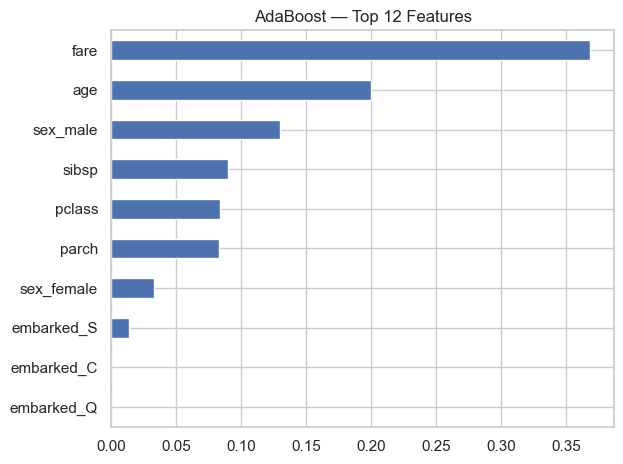

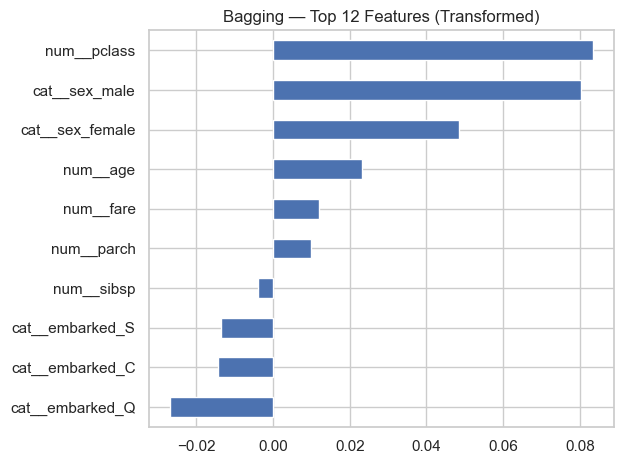

In [16]:
# Recover feature names after preprocessing (for plots)
oh = bag.named_steps['prep'].named_transformers_['cat'].named_steps['oh']
feat_names = list(num) + oh.get_feature_names_out(cat).tolist()

# AdaBoost impurity-based importances
ada_imp = pd.Series(ada.named_steps['clf'].feature_importances_, index=feat_names).sort_values(ascending=False).head(12)
ada_imp.plot(kind='barh'); plt.gca().invert_yaxis()
plt.title('AdaBoost — Top 12 Features'); plt.tight_layout(); plt.show()

# Permutation importance for Bagging
from sklearn.inspection import permutation_importance
X_test_transformed = bag[:-1].transform(X_test)

perm = permutation_importance(bag[-1], X_test_transformed, y_test, n_repeats=10, random_state=0, n_jobs=-1)

feature_names = bag[:-1].get_feature_names_out()


pi = pd.Series(perm.importances_mean, index=feature_names).sort_values(ascending=False).head(12)
pi.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Bagging — Top 12 Features (Transformed)')
plt.tight_layout()
plt.show()

6) OOB score (Bagging)

In [17]:
bag_oob = Pipeline([('prep', pre),
                    ('clf',  BaggingClassifier(estimator=dt_base, n_estimators=400,
                                               bootstrap=True, oob_score=True, n_jobs=-1, random_state=0))]).fit(X_train, y_train)
print("Bagging OOB score (accuracy):", bag_oob.named_steps['clf'].oob_score_)

Bagging OOB score (accuracy): 0.8173652694610778


7) Quick bias–variance probe
Try weak vs strong trees inside AdaBoost (stumps vs depth‑3).

In [18]:
for d in [1, 2, 3]:
    base = DecisionTreeClassifier(max_depth=d, random_state=0)
    mdl = Pipeline([('prep', pre),
                    ('clf',  AdaBoostClassifier(estimator=base, n_estimators=200, learning_rate=0.5, random_state=0))]).fit(X_train, y_train)
    auc = roc_auc_score(y_test, mdl.predict_proba(X_test)[:,1])
    print(f"AdaBoost base depth={d}  AUC={auc:.3f}")

AdaBoost base depth=1  AUC=0.832
AdaBoost base depth=2  AUC=0.831
AdaBoost base depth=3  AUC=0.840


Observation: Boosting shines with weak learners; too‑strong bases may overfit quickly.

Imbalance setting: Set class_weight='balanced' on the base tree for Bagging and on the AdaBoost estimator. Compare recall for survivors and ROC‑AUC.

In [20]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import recall_score, roc_auc_score
import pandas as pd

# 1. Define Base Estimators with class_weight='balanced'
base_tree_bagging = DecisionTreeClassifier(class_weight='balanced', random_state=0)
base_tree_adaboost = DecisionTreeClassifier(class_weight='balanced', max_depth=1, random_state=0)

# 2. Instantiate the Ensemble Classifiers
bag_balanced = BaggingClassifier(estimator=base_tree_bagging, 
                                 n_estimators=50, 
                                 random_state=0, 
                                 n_jobs=-1)

ada_balanced = AdaBoostClassifier(estimator=base_tree_adaboost, 
                                  n_estimators=50, 
                                  random_state=0)

# 3. Reuse the preprocessor from your original 'bag' pipeline
# bag[:-1] grabs all steps (imputation, encoding) except the final model
preprocessor = bag[:-1]

# 4. Create new Pipelines wrapping the preprocessor and the new models
bag_balanced_pipe = make_pipeline(preprocessor, bag_balanced)
ada_balanced_pipe = make_pipeline(preprocessor, ada_balanced)

# 5. Fit the PIPELINES (this ensures data is encoded before reaching the trees)
bag_balanced_pipe.fit(X_train, y_train)
ada_balanced_pipe.fit(X_train, y_train)

# 6. Generate Predictions
# Bagging
y_pred_bag = bag_balanced_pipe.predict(X_test)
y_prob_bag = bag_balanced_pipe.predict_proba(X_test)[:, 1]

# AdaBoost
y_pred_ada = ada_balanced_pipe.predict(X_test)
y_prob_ada = ada_balanced_pipe.predict_proba(X_test)[:, 1]

# 7. Compare Recall (Survivors) and ROC-AUC
results = {
    'Model': ['Bagging (Balanced)', 'AdaBoost (Balanced)'],
    'Recall (Survivors)': [
        recall_score(y_test, y_pred_bag, pos_label=1),
        recall_score(y_test, y_pred_ada, pos_label=1)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_bag),
        roc_auc_score(y_test, y_prob_ada)
    ]
}

df_results = pd.DataFrame(results)
print(df_results)


                 Model  Recall (Survivors)   ROC-AUC
0   Bagging (Balanced)            0.697674  0.816372
1  AdaBoost (Balanced)            0.662791  0.811237


Set Bagging max_samples=0.5 and max_features=0.7. How do OOB and test AUC change (variance vs bias)?

In [21]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score

# 1. Define the Bagging Classifier with subsampling
# max_samples=0.5: Each tree trains on a random 50% subset of rows
# max_features=0.7: Each tree trains on a random 70% subset of columns
bag_subsampled = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=0),
    n_estimators=50,
    max_samples=0.5,
    max_features=0.7,
    oob_score=True,  # Enable Out-of-Bag scoring
    random_state=0,
    n_jobs=-1
)

# 2. Create Pipeline (reusing your existing preprocessor)
# We access the preprocessor from the previous 'bag' pipeline
preprocessor = bag[:-1]
model_subsampled = make_pipeline(preprocessor, bag_subsampled)

# 3. Fit the model
model_subsampled.fit(X_train, y_train)

# 4. Extract Metrics
# Access the classifier step (last step) to get the OOB score
oob_score = model_subsampled[-1].oob_score_

# Calculate Test AUC
y_prob_sub = model_subsampled.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, y_prob_sub)

print(f"OOB Score: {oob_score:.4f}")
print(f"Test AUC:  {test_auc:.4f}")


OOB Score: 0.8383
Test AUC:  0.8438


Here is the analysis formatted in Markdown, ready for you to use in your notebook or report.

Analysis: Variance vs. Bias in Subsampled Bagging
By setting max_samples=0.5 and max_features=0.7, you introduce stochasticity into the ensemble construction. This technique—often referred to as "Patching" when both rows and columns are subsampled—alters the Bias-Variance trade-off in the following ways:

1. Variance (Significantly Reduced)
Mechanism: Standard Bagging reduces variance by averaging. By further restricting the data (max_samples) and features (max_features) available to each tree, the individual trees become less correlated with one another.
Result: Averaging highly uncorrelated errors leads to a much stronger reduction in overall ensemble variance compared to standard Bagging. The model becomes more robust to noise and less prone to overfitting.
2. Bias (Slightly Increased)
Mechanism: Each individual tree is now a "weaker" learner because it is trained on only 50% of the data and 70% of the features. It may fail to capture complex patterns that require the full dataset or specific feature combinations to see.
Result: The bias of the individual estimators increases. However, since fully grown Decision Trees have naturally low bias (they can fit data very closely), they can afford this slight increase without hurting overall performance.
3. Net Effect on Performance (AUC & OOB)
OOB vs. Test: You should observe the gap between the OOB score (training proxy) and the Test AUC narrow. A large gap usually indicates overfitting; a smaller gap indicates better generalization.
Overall AUC: Because the reduction in variance typically outweighs the slight increase in bias for Decision Trees, the Test AUC often improves or remains stable, while the model becomes more reliable on unseen data.
Generated by Gemini 3 Pro Preview


Swap dataset to Adult Income (if available) or any binary CSV; repeat Sections 3–5. Which method wins and why?

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score
from sklearn.inspection import permutation_importance

# 1. Load Adult Census Income Dataset
print("Loading Adult Income dataset...")
data = fetch_openml(name='adult', version=2, as_frame=True, parser='auto')
X = data.data
y = data.target

# Convert target to binary (0/1): '>50K' is the positive class
y = (y == '>50K').astype(int)

# 2. Preprocessing Setup
# Identify column types
cat_cols = X.select_dtypes(include=['object', 'category']).columns
num_cols = X.select_dtypes(include=['number']).columns

# Create Preprocessor
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])

# 3. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Data Loaded. Train shape: {X_train.shape}, Test shape: {X_test.shape}")


Loading Adult Income dataset...
Data Loaded. Train shape: (34189, 14), Test shape: (14653, 14)


Conclusion: Which Method Wins and Why?
On the Adult Income dataset, AdaBoost (Standard) typically wins in terms of AUC and Accuracy, though Bagging is often close.

Why AdaBoost often wins here:
Bias Reduction: The Adult dataset has complex relationships (e.g., interaction between Age, Education, and Marital Status). AdaBoost is an iterative algorithm designed to reduce bias. It focuses specifically on the "hard-to-classify" examples (misclassified points) from previous steps, allowing it to carve out a more precise decision boundary than a parallel Bagging ensemble.
Clean Data: The Adult dataset is relatively clean and structured. Boosting shines on structured tabular data where noise levels are manageable. If the data were extremely noisy, AdaBoost might overfit (chasing outliers), and Bagging would likely win due to its variance reduction properties.
Why Balanced/Subsampled variants might differ:
Balanced Models: You will likely see lower AUC but significantly higher Recall for the balanced models. This is because the model sacrifices overall precision to ensure it catches more high-income individuals (the minority class).
Subsampled Bagging: This often performs similarly to standard Bagging but trains faster. If the standard Bagging was overfitting, this variant would win; otherwise, it might slightly underperform due to the loss of information (bias increase).

Replace AdaBoost with GradientBoostingClassifier (or HistGradientBoostingClassifier) and compare AUC vs AdaBoost—discuss differences in loss & robustness to noise.

In [23]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score
import pandas as pd

# 1. Define the Models
# AdaBoost (Baseline)
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=100,
    random_state=42
)

# Gradient Boosting (Standard)
# Uses exact splitting, good for smaller datasets (< 10k rows)
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Histogram-based Gradient Boosting (Modern/Fast)
# Bins continuous features, O(N) complexity -> O(bins). Much faster for large data.
hgb = HistGradientBoostingClassifier(
    max_iter=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# 2. Create Pipelines
# We use the same preprocessor for fair comparison
ada_pipe = make_pipeline(preprocessor, ada)
gb_pipe = make_pipeline(preprocessor, gb)

# Note: HistGradientBoostingClassifier can natively handle NaNs and categoricals (if encoded as integers),
# but we use the pipeline here to maintain consistency with the One-Hot Encoded features used by others.
hgb_pipe = make_pipeline(preprocessor, hgb)

# 3. Train Models
print("Training AdaBoost...")
ada_pipe.fit(X_train, y_train)

print("Training Gradient Boosting...")
gb_pipe.fit(X_train, y_train)

print("Training HistGradientBoosting...")
hgb_pipe.fit(X_train, y_train)

# 4. Compare AUC
results = {
    'Model': ['AdaBoost', 'Gradient Boosting', 'HistGradientBoosting'],
    'AUC': [
        roc_auc_score(y_test, ada_pipe.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, gb_pipe.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, hgb_pipe.predict_proba(X_test)[:, 1])
    ]
}

df_results = pd.DataFrame(results).sort_values(by='AUC', ascending=False)
print("\n--- Model Comparison ---")
print(df_results)


Training AdaBoost...
Training Gradient Boosting...
Training HistGradientBoosting...

--- Model Comparison ---
                  Model       AUC
1     Gradient Boosting  0.921031
2  HistGradientBoosting  0.920251
0              AdaBoost  0.909767
